# Phase 4 DoD — topology & the homogeneity metric

**Aim:** show that with the **same persona set**, swapping the interaction *topology* produces a **measurably different homogeneity metric** — the Phase-4 spike (*how much does the divergence metric change under different graph structures at this N?*). Topology is a pluggable, seeded, swappable parameter (R4/R10/R13); the homogeneity read is the P4-scoped instrument in `src/polis/metrics.py` (dominant-share / distinct / normalised entropy over the population's SPEAK stances), defined before the run per R14. The full R14–R17 dashboard, embedding-distance metrics, and the R16 null-model baseline are P5 and build on this same kernel (ADR 0012).

The engine lives in `src/polis`; this notebook only imports down and measures. Deterministic coverage is in `tests/test_topology.py`, `tests/test_metrics.py`, and the P4 additions to `tests/test_simulation.py`.

**Bounded honestly (R27):** the signal is what agents *say* — an ABSTAIN contributes no stance that tick — so a low reading is *stance concentration*, not proof of internal consensus. The narrow SPEAK/ABSTAIN action space (ADR 0008) can suppress observable divergence; that ceiling is a separate P5 check.

In [1]:
import os
from collections import Counter

import pandas as pd
from plotnine import (aes, geom_col, geom_line, geom_point, facet_wrap, ggplot,
                      labs, scale_x_continuous, theme_minimal, ylim)

from polis.agent import Agent, committed
from polis.embeddings import EmbeddingModel
from polis.llm import LLMClient
from polis.memory_seeds import EVENING_SEEDS, MORNING_SEEDS, SHARED_PERSONA, build_store
from polis.metrics import homogeneity, homogeneity_trajectory, stance_distribution
from polis.persona import Persona
from polis.questions import DST_OPTIONS, DST_QUESTION
from polis.runlog import RunLog
from polis.scheduler import SchedulerConfig
from polis.simulation import DynamicsConfig, Population, Simulation
from polis.topology import FullyConnected, SmallWorld, StochasticBlock

In [2]:
# --- config: edit and re-run downward ---
N_AGENTS = 20            # 10 evening / 10 morning, aligned to the 2 SBM blocks
TICKS = 4                # convergence is fast under full exposure; 4 shows the plateau
CONCURRENCY = 8          # in-flight-request cap (R5), reused from P3
SEED = 1                 # seeds the graphs and the run
SUPPORT = len(DST_OPTIONS)   # normalise entropy against the full option set
DATA_CSV = '../../data/phase4_topology.csv'
DB_DIR = '.'             # per-config SQLite logs beside this notebook

# Short labels for the four DST options, for readable plots.
STANCE_SHORT = {DST_OPTIONS[0]: 'perm. DST', DST_OPTIONS[1]: 'perm. standard',
                DST_OPTIONS[2]: 'keep switching', DST_OPTIONS[3]: 'no preference'}

In [3]:
# Same shared neutral persona as P1/P3; only the seeded memories differ, so any
# divergence is attributable to memory + topology, not identity (R7 depth is P5).
# Camps are CONTIGUOUS (first half evening, second half morning) so the stochastic
# block model's two blocks line up with the two memory camps.
client = LLMClient()
embedder = EmbeddingModel()

def build_population():
    agents = []
    for i in range(N_AGENTS):
        persona = Persona(f'resident_{i:02d}', SHARED_PERSONA.description, SHARED_PERSONA.temperature)
        seeds = EVENING_SEEDS if i < N_AGENTS // 2 else MORNING_SEEDS
        agents.append(Agent(persona, client, embedder=embedder, memory=build_store(embedder, seeds)))
    return Population(agents)

TOPOLOGIES = {
    'fully_connected': FullyConnected(),                                  # R10 control: everyone hears everyone
    'small_world': SmallWorld(k=4, p=0.2, seed=SEED),                    # sparse, short paths
    'stochastic_block': StochasticBlock(n_blocks=2, p_in=0.7, p_out=0.03, seed=SEED),  # two clustered camps
}
print('model:', client.config.model, '| agents:', N_AGENTS, '| ticks:', TICKS)
print('topologies:', {k: v.to_config() for k, v in TOPOLOGIES.items()})

model: qwen/qwen3-32b | agents: 20 | ticks: 4
topologies: {'fully_connected': {'name': 'fully_connected'}, 'small_world': {'name': 'small_world', 'k': 4, 'p': 0.2, 'seed': 1}, 'stochastic_block': {'name': 'stochastic_block', 'n_blocks': 2, 'p_in': 0.7, 'p_out': 0.03, 'seed': 1}}


## 1. One run end-to-end — the metric is readable from the log

A single `fully_connected` run: the population starts 10/10 split, and full exposure is the maximum consensus pressure (R10). We read the per-tick homogeneity trajectory straight back from the SQLite run log — `dominant_share` rising / `entropy` falling is convergence, logged as a trajectory (R15-style) rather than only at the endpoint.

In [4]:
def run_topology(name, topo, build=build_population):
    db = os.path.join(DB_DIR, f'phase4_{name}.db')
    if os.path.exists(db):
        os.remove(db)
    sim = Simulation(build(), topology=topo, logger=RunLog.open(db),
                     dynamics=DynamicsConfig(seed=SEED),
                     scheduler_config=SchedulerConfig(max_concurrency=CONCURRENCY))
    run = sim.run(TICKS)
    return sim, run

sim0, run0 = run_topology('fully_connected', TOPOLOGIES['fully_connected'])
traj0 = homogeneity_trajectory(run0, support=SUPPORT)
assert run0.throughput['failures'] == 0, 'a decide failed'
print(f"run_id {run0.run_id[:12]} | topology {run0.config['topology']}")
print(f"{run0.throughput['n_calls']} decides, {run0.throughput['failures']} failures, "
      f"{run0.throughput['total_tokens']} tokens")
for r in traj0:
    print(f"  tick {r['tick']}: dom_share={r['dominant_share']:.2f} distinct={r['distinct']} "
          f"entropy={r['entropy']:.2f} top={STANCE_SHORT.get(r['dominant_stance'], r['dominant_stance'])}")
sim0.log.close()

C:\Users\Ryan R\Documents\DS_Projects_Local\AS-Technical-Task\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 21338.24it/s]

run_id f68736ec9fb3 | topology {'name': 'fully_connected'}
80 decides, 0 failures, 48083 tokens
  tick 0: dom_share=0.50 distinct=2 entropy=0.50 top=perm. DST
  tick 1: dom_share=1.00 distinct=1 entropy=0.00 top=perm. DST
  tick 2: dom_share=1.00 distinct=1 entropy=0.00 top=perm. DST
  tick 3: dom_share=1.00 distinct=1 entropy=0.00 top=perm. DST


## 2. Same personas, three topologies — the DoD

The identical persona set (same seeds, same order) is run under each topology; only the graph changes. We record the per-tick homogeneity trajectory (free, from the log) and take one `population.survey()` at the end as an endpoint confirmation in the deliverable's own units (the headline op). The DoD is met when the trajectories/endpoints differ measurably across topologies.

In [5]:
traj_rows, summary_rows, survey_rows = [], [], []
for name, topo in TOPOLOGIES.items():
    sim, run = run_topology(name, topo)
    traj = homogeneity_trajectory(run, support=SUPPORT)
    for r in traj:
        traj_rows.append({'topology': name, **r})
    # Endpoint confirmation in survey units (Layer 5 op), written back per R19.
    survey = run.log and sim.population.survey(DST_QUESTION)
    sdist = Counter(a['choice'] for a in survey)
    sh = homogeneity(sdist, support=SUPPORT)
    for choice, n in sdist.items():
        survey_rows.append({'topology': name, 'stance': STANCE_SHORT.get(choice, choice), 'n': n})
    summary_rows.append({
        'topology': name,
        'final_dom_share': traj[-1]['dominant_share'], 'final_entropy': traj[-1]['entropy'],
        'final_distinct': traj[-1]['distinct'],
        'survey_dom_share': sh['dominant_share'], 'survey_entropy': sh['entropy'],
        'decides': run.throughput['n_calls'], 'failures': run.throughput['failures'],
        'tokens': run.throughput['total_tokens']})
    print(f"{name:>18}: final dom_share {traj[-1]['dominant_share']:.2f} / entropy {traj[-1]['entropy']:.2f} "
          f"| survey dom_share {sh['dominant_share']:.2f} | failures {run.throughput['failures']}")
    sim.log.close()

traj_df = pd.DataFrame(traj_rows)
summary = pd.DataFrame(summary_rows)
os.makedirs(os.path.dirname(DATA_CSV), exist_ok=True)
traj_df.to_csv(DATA_CSV, index=False)
assert (summary['failures'] == 0).all(), 'a config had decide failures'
summary

   fully_connected: final dom_share 1.00 / entropy 0.00 | survey dom_share 1.00 | failures 0


       small_world: final dom_share 0.55 / entropy 0.50 | survey dom_share 0.60 | failures 0


  stochastic_block: final dom_share 0.55 / entropy 0.50 | survey dom_share 0.50 | failures 0


,topology,final_dom_share,final_entropy,final_distinct,survey_dom_share,survey_entropy,decides,failures,tokens
0,fully_connected,1.00,0.000000,1,1.0,0.000000,80,0,47604
1,small_world,0.55,0.496387,2,0.6,0.485475,80,0,45802
2,stochastic_block,0.55,0.496387,2,0.5,0.500000,80,0,47060


## 3. Homogeneity trajectory vs topology

Dominant-share (fraction of the population on the plurality stance; 1.0 = unanimous) and normalised entropy (0 = consensus, 1 = uniform over the four options) per tick. Diverging curves = topology changing the convergence path on identical personas.

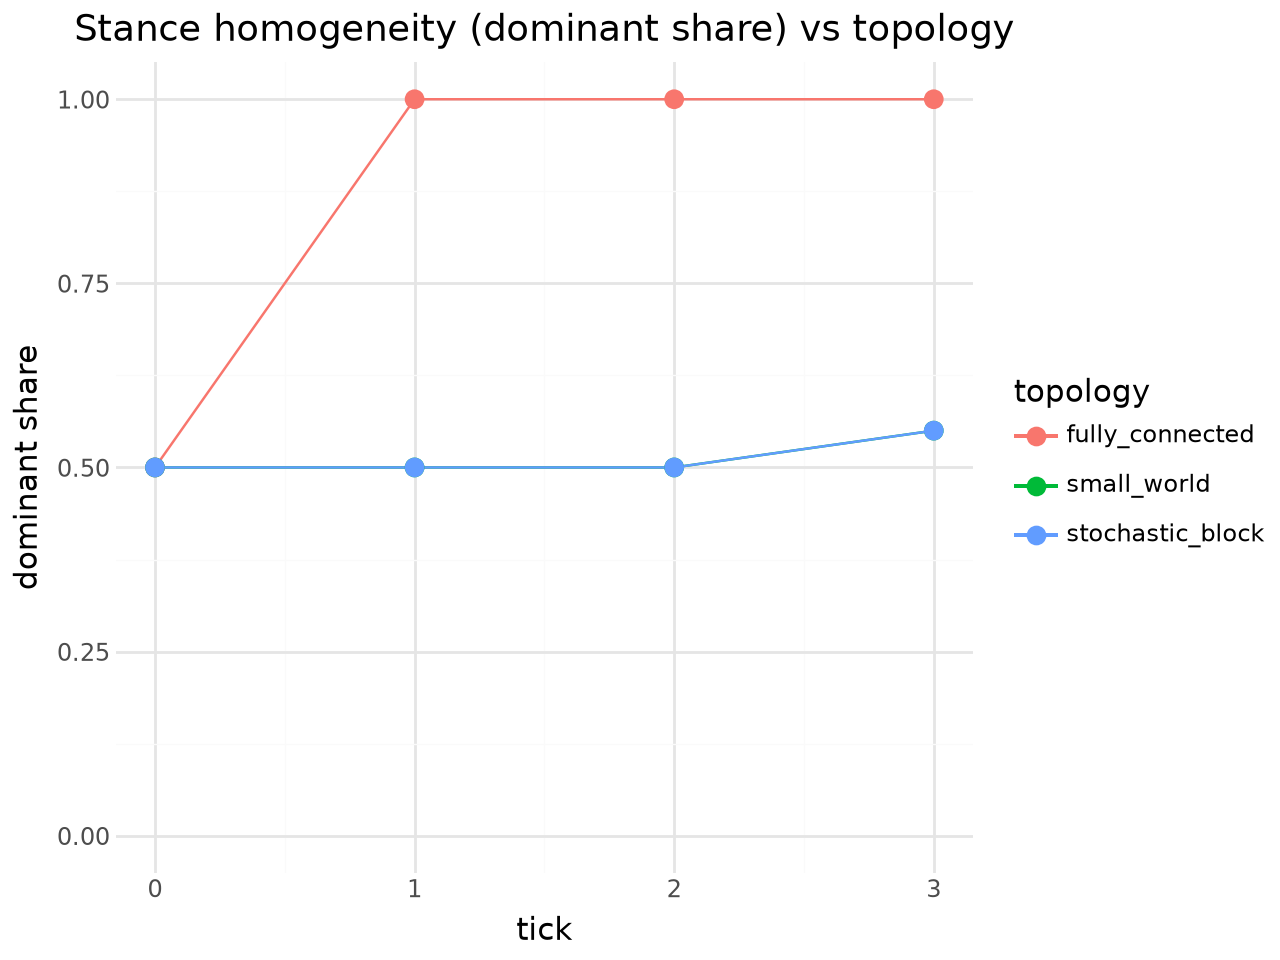

In [6]:
(ggplot(traj_df, aes('tick', 'dominant_share', color='topology'))
 + geom_line() + geom_point(size=3)
 + scale_x_continuous(breaks=list(range(TICKS)))
 + ylim(0, 1)
 + labs(title='Stance homogeneity (dominant share) vs topology',
        x='tick', y='dominant share', color='topology')
 + theme_minimal())

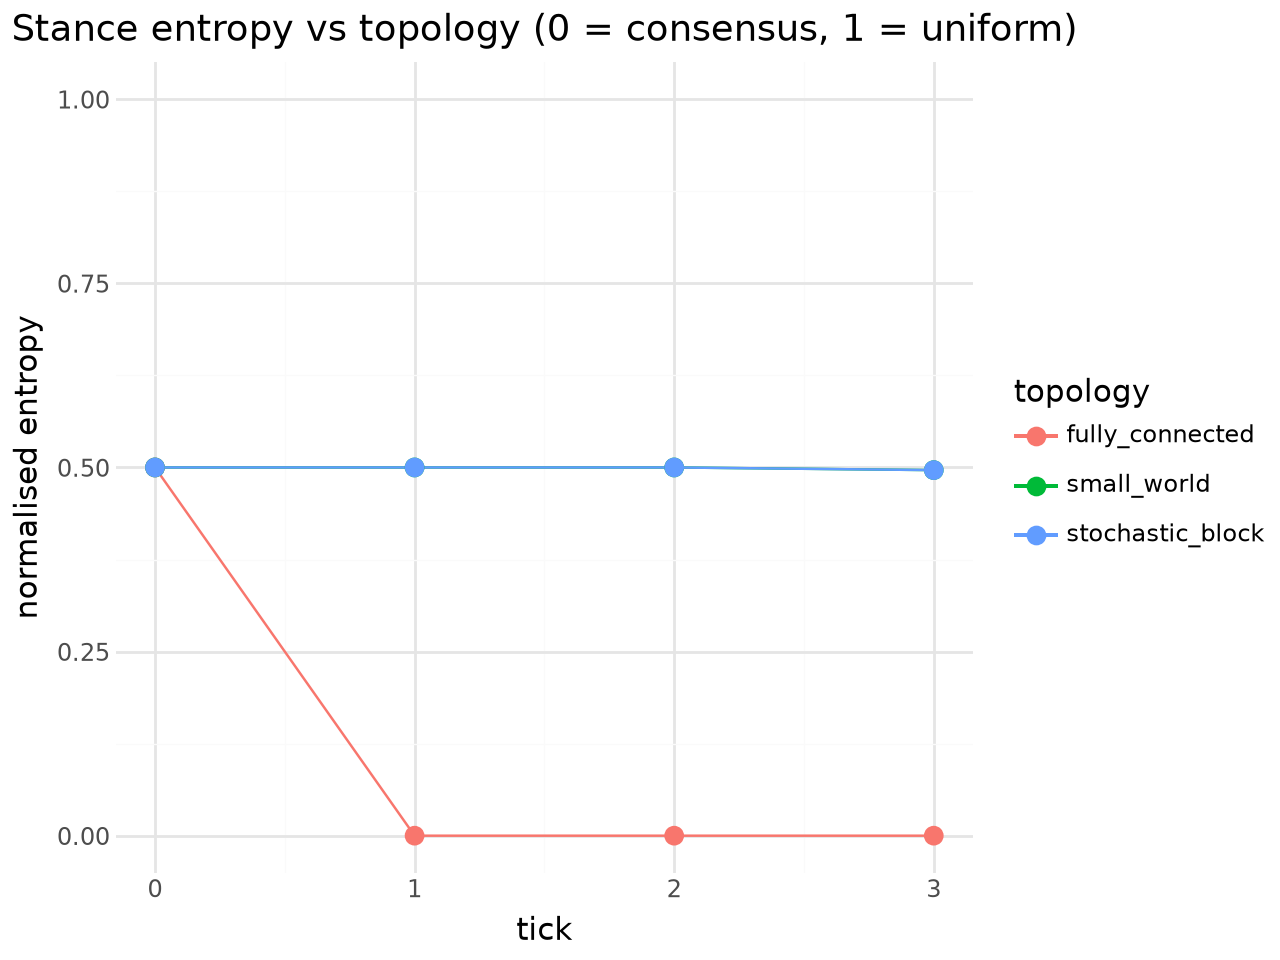

In [7]:
(ggplot(traj_df, aes('tick', 'entropy', color='topology'))
 + geom_line() + geom_point(size=3)
 + scale_x_continuous(breaks=list(range(TICKS)))
 + ylim(0, 1)
 + labs(title='Stance entropy vs topology (0 = consensus, 1 = uniform)',
        x='tick', y='normalised entropy', color='topology')
 + theme_minimal())

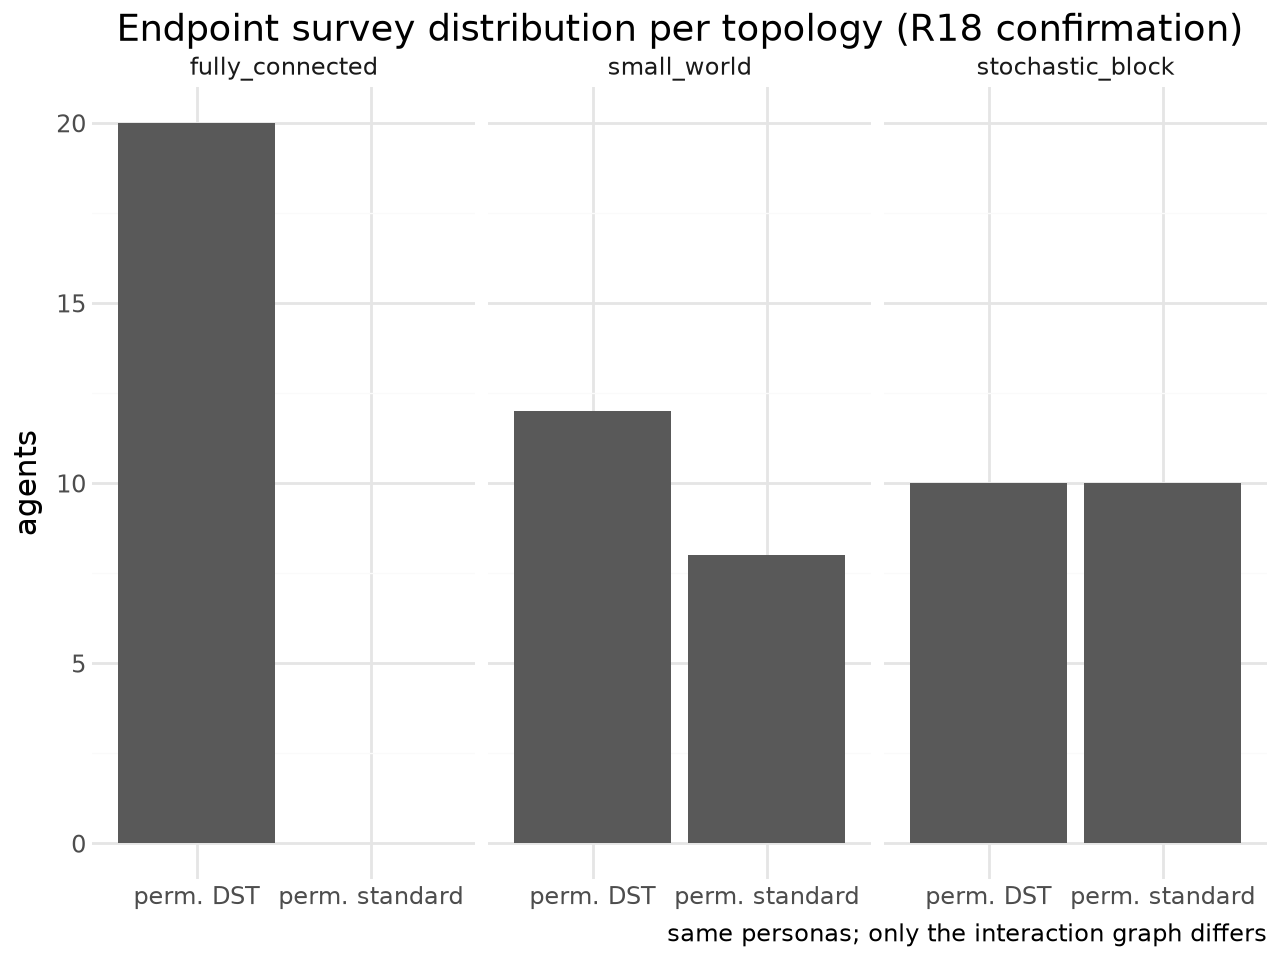

In [8]:
survey_df = pd.DataFrame(survey_rows)
(ggplot(survey_df, aes('stance', 'n'))
 + geom_col()
 + facet_wrap('~topology')
 + labs(title='Endpoint survey distribution per topology (R18 confirmation)',
        x='', y='agents')
 + theme_minimal()
 + labs(caption='same personas; only the interaction graph differs'))

## 4. Committed minority (R11) — topology gates a faction's fate

A committed sub-population holds a fixed stance and never updates (R11: minorities above a critical size can flip majority conventions). Here 4 agents in the morning camp are **committed to permanent standard time**, and the *same* population runs under `fully_connected` (the faction is heard by everyone each tick) and `stochastic_block` (the faction is confined to its own block, `p_out` small). The question is how topology mediates the faction's fate: does full exposure let it spread, or does the global-consensus cascade seen in §2 swamp it while the clustered graph shelters it? We read the share of the *non-committed* agents whose final SPEAK is the committed stance — the faction's actual persuasive effect.

In [9]:
N_COMMITTED = 4
COMMITTED_STANCE = DST_OPTIONS[1]  # permanent standard time
COMMITTED_IDS = {f'resident_{i:02d}' for i in range(N_AGENTS // 2, N_AGENTS // 2 + N_COMMITTED)}

def build_committed_population():
    agents = []
    for i in range(N_AGENTS):
        persona = Persona(f'resident_{i:02d}', SHARED_PERSONA.description, SHARED_PERSONA.temperature)
        seeds = EVENING_SEEDS if i < N_AGENTS // 2 else MORNING_SEEDS
        store = build_store(embedder, seeds)
        if persona.id in COMMITTED_IDS:
            agents.append(committed(persona, client, COMMITTED_STANCE, embedder=embedder, memory=store))
        else:
            agents.append(Agent(persona, client, embedder=embedder, memory=store))
    return Population(agents)

def non_committed_share_of(run, stance):
    '''Share of the *non-committed* agents whose latest SPEAK is `stance` — the
    faction's actual persuasive effect, excluding the committed agents themselves.'''
    latest = {}
    for e in run.events(event_type='action'):
        p = e['payload']
        if e['agent_id'] in COMMITTED_IDS:
            continue
        if p.get('action_type') == 'speak' and p.get('stance'):
            latest[e['agent_id']] = p['stance']
    if not latest:
        return 0.0
    return sum(v == stance for v in latest.values()) / len(latest)

comm_rows = []
for name in ('fully_connected', 'stochastic_block'):
    sim, run = run_topology(f'committed_{name}', TOPOLOGIES[name], build=build_committed_population)
    share = non_committed_share_of(run, COMMITTED_STANCE)
    conf = run.config['committed']
    comm_rows.append({'topology': name, 'noncommitted_on_standard': share, 'committed': len(conf)})
    print(f"{name:>18}: {share:.2f} of non-committed agents adopted the committed stance "
          f"({len(conf)} committed, no model call)")
    sim.log.close()
pd.DataFrame(comm_rows)

   fully_connected: 0.00 of non-committed agents adopted the committed stance (4 committed, no model call)


  stochastic_block: 0.31 of non-committed agents adopted the committed stance (4 committed, no model call)


,topology,noncommitted_on_standard,committed
0,fully_connected,0.0000,4
1,stochastic_block,0.3125,4


## Verdict

**DoD met.** The same persona set under different topologies gives a **starkly different homogeneity metric** (§2–3), with `failures == 0` across every config. `fully_connected` collapses to unanimity by tick 1 (dominant share 0.50 → 1.00, entropy → 0.00), while `small_world` and `stochastic_block` hold near-even diversity for the whole run (final dominant share 0.55, entropy ≈ 0.50). The endpoint surveys agree (dominant share 1.00 vs 0.60 vs 0.50). Full exposure biases toward global consensus exactly as R10 warns; the sparse/clustered graphs preserve the initial split. Topology is a versioned run parameter (`config['topology']` = name + params + seed, R4/R17), swapped at runtime by handing `Simulation` a different `Topology` (R13).

**§4 — the committed minority (R11) cuts the opposite way from the naïve intuition.** The identical 4-agent perm-standard faction persuades **0%** of the non-committed agents under `fully_connected` but **31%** under `stochastic_block`. Full connectivity does not amplify the faction — it drowns it: the same global-consensus cascade that produced unanimity in §2 overruns four fixed voices. The clustered graph *shelters* the faction inside its block, where it keeps local influence. Sparse/clustered topology preserving a committed minority against a global majority is the R10 + R11 result in a single comparison.

**Scope honesty.** The homogeneity read here is the P4 instrument (stance concentration), not the full validation layer: embedding pairwise-distance / cluster count (rest of R14), the continuous dashboard, and the R16 null-model baseline are P5 and build on `metrics.homogeneity` (ADR 0012). The finding is bounded by action-space adequacy (R27, ADR 0008): a narrow SPEAK/ABSTAIN space can cap observable divergence, checked separately at P5. Topology-mutating (tie) actions (R26) are a reserved event-stream seam (`EVENT_TIE_CHANGE`), not built this phase — the graph is static within a run and swapped only *between* runs for the R13 counterfactual.